In [16]:
# Package
from pathlib import Path
from random import seed
import sys

ROOT = Path.cwd().parent   # …/DP_GINI
sys.path.insert(0, str(ROOT / "src"))

from DPGini.utils import cal_gini, cal_gini, sort_X

import DPGini as dg
from DPGini.core import (
    cal_beta, smooth_upper_bound, cal_su_fast, sample_eta, add_dp_noise_gini, simulate_noisy_gini, laplace, above_threshold, unbounded_quantile_mech
)
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from matplotlib.patches import Patch
from pandas import DataFrame

In [17]:
# DP histogram by adding Laplace noise to each bin count.

def dp_histogram_laplace(x, bins, data_range, epsilon, seed=None):
    rng = np.random.default_rng(seed)

    counts, edges = np.histogram(x, bins=bins, range=data_range)

    # add/remove adjacency => L1 sensitivity of histogram counts is 1
    noisy_counts = counts + rng.laplace(loc=0.0, scale=1.0 / epsilon, size=counts.shape)

    # post-processing: clamp negatives to 0 
    noisy_counts = np.maximum(noisy_counts, 0.0)

    return noisy_counts, edges
def sample_synthetic_from_dp_hist(noisy_counts, edges, n, seed=None):
    """
    Sample n synthetic values from a DP histogram (post-processing).
    """
    rng = np.random.default_rng(seed)

    total = noisy_counts.sum()
    if total <= 0:
        raise ValueError("All noisy counts are zero; increase epsilon or adjust bins/range.")

    probs = noisy_counts / total
    idx = rng.choice(len(noisy_counts), size=n, p=probs)

    # sample uniformly within each chosen bin
    lows = edges[idx]
    highs = edges[idx + 1]
    return rng.uniform(lows, highs)

In [18]:
path = ROOT / "data" / "asecpub24csv"/ f"pppub24.csv"
df = pd.read_csv(path, low_memory=False)
cols = [c for c in ["PH_SEQ","PPPOS","A_AGE","MARSUPWT","PTOTVAL"] if c in df.columns]
d = df[cols].copy()
del df

# Coerce numerics
for c in ["A_AGE","MARSUPWT","PTOTVAL"]:
    if c in d.columns:
        d[c] = pd.to_numeric(d[c], errors="coerce")


mask = (
        (d["A_AGE"] >= 18) &
        #(d["A_AGE"] >= 65) &
        (d["MARSUPWT"] > 0) &
        (d["PTOTVAL"].notna())
    )
df_clean = d[mask].copy()
df_clean = df_clean[df_clean["PTOTVAL"] >= 0]

s = pd.to_numeric(df_clean["PTOTVAL"], errors="coerce")
min_all = s.min()
max_all = s.max()
mean_all = s.mean()
X = np.sort(s.to_numpy(dtype=np.float64, copy=False))
g_real = cal_gini(X)
print("PTOTVAL min:", min_all)
print("PTOTVAL max:", max_all)
print("PTOTVAL mean:", mean_all)
print("Gini of the real dataset", g_real)
rate = max_all / mean_all
print("Max/mean ratio:", rate)

PTOTVAL min: 0
PTOTVAL max: 2108379
PTOTVAL mean: 58878.250976589305
Gini of the real dataset 0.5512699892465565
Max/mean ratio: 35.8091309614193


In [22]:

alpha = len(X) / np.sum(np.log(X/ min_all))

if alpha <= 0.5:
    gini_pareto = np.inf     # 或者 raise
else:
    gini_pareto = 1.0 / (2 * alpha - 1)

print("alpha =", alpha)
print("Gini_from_Pareto =", gini_pareto)

alpha = nan
Gini_from_Pareto = nan


C:\Users\wenji\AppData\Local\Temp\ipykernel_32584\1211583116.py:1: RuntimeWarning: divide by zero encountered in divide
  alpha = len(X) / np.sum(np.log(X/ min_all))
C:\Users\wenji\AppData\Local\Temp\ipykernel_32584\1211583116.py:1: RuntimeWarning: invalid value encountered in divide
  alpha = len(X) / np.sum(np.log(X/ min_all))


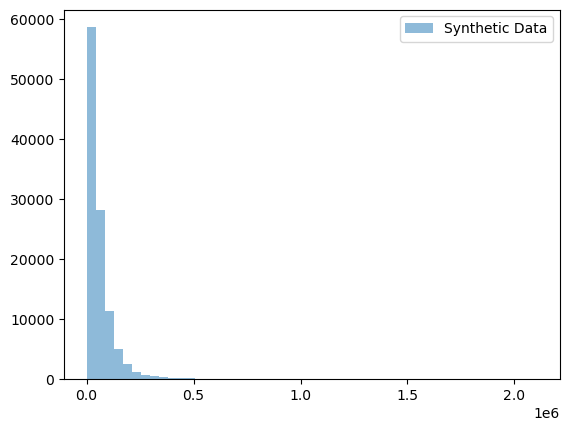

0.5170154344074187


In [5]:
# Generate Synthetic Data by dp_histogram
U = s.max()
L = 0
bin = 50
epsilon = 1
noisy_counts, edges = dp_histogram_laplace(s, bins=bin, data_range=(L, U), epsilon=epsilon, seed=1)
synthetic_data = sample_synthetic_from_dp_hist(noisy_counts, edges, n=len(df_clean), seed=1)

# plot histogram 
plt.hist(synthetic_data, bins=bin, range=(L, U), alpha=0.5, label='Synthetic Data')
# plt.hist(s, bins=bin, range=(L, U), alpha=0.5, label='Original Data')
plt.legend()
plt.show()
synthetic_data = np.sort(synthetic_data)
g = cal_gini(synthetic_data)
print(g)

In [14]:
eps = [0.25, 0.5, 1, 1.5, 2]
bins = [50, 100, 200, 400, 500]
n_sample = 10000
# g_syn dim: bins x eps x n_sample
g_syn = np.zeros((len(bins), len(eps), n_sample))

for b_idx, b in enumerate(bins):
    for e_idx, epsilon in enumerate(eps):
        for i in range(n_sample):
            noisy_counts, edges = dp_histogram_laplace(s, bins=b, data_range=(L, U), epsilon=epsilon, seed=i)
            synthetic_data = sample_synthetic_from_dp_hist(noisy_counts, edges, n=len(df_clean), seed=i)
            synthetic_data = np.sort(synthetic_data)
            g = cal_gini(synthetic_data)
            g_syn[b_idx, e_idx, i] = g

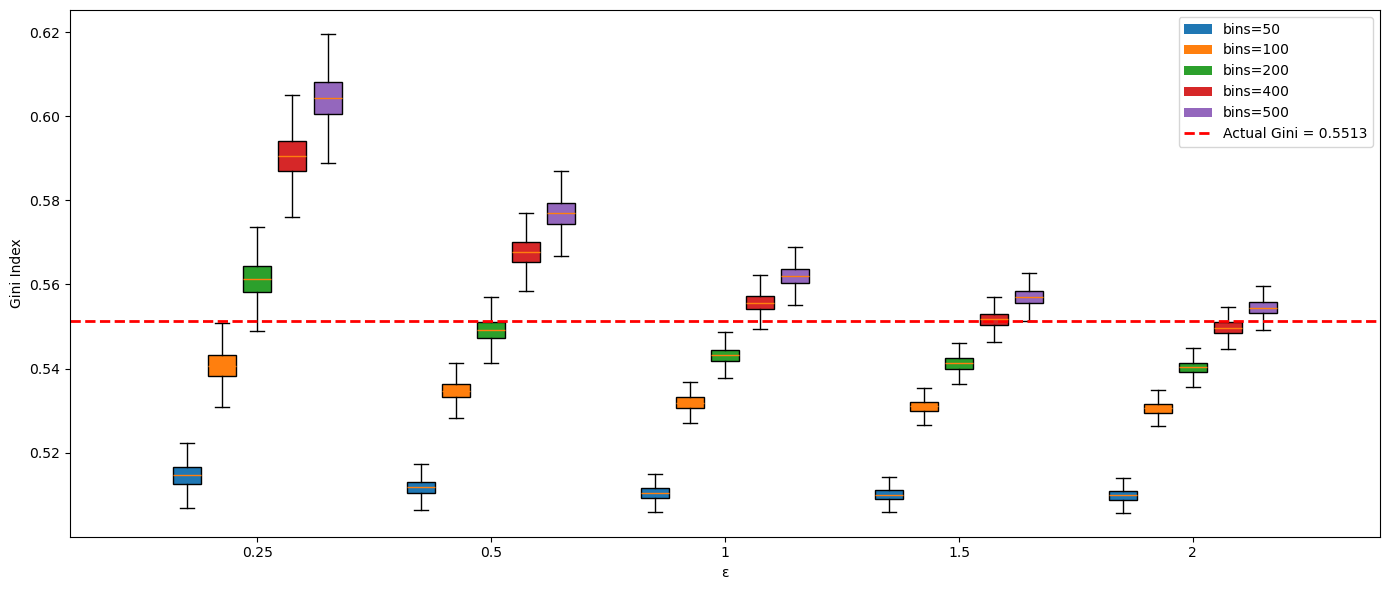

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for grouped boxplot
n_eps = len(eps)
n_bins = len(bins)
positions = []
data = []
colors = plt.cm.tab10.colors[:n_bins]

width = 0.15
group_spacing = 1.0

for e_idx in range(n_eps):
    group_center = e_idx * group_spacing
    for b_idx in range(n_bins):
        pos = group_center + (b_idx - (n_bins - 1) / 2) * width
        positions.append(pos)
        data.append(g_syn[b_idx, e_idx, :n_sample])

# Create boxplot without outliers
bp = ax.boxplot(data, positions=positions, widths=width * 0.8, showfliers=False, patch_artist=True)

# Color the boxes by bin
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % n_bins])

# Create legend for bins
legend_patches = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[i]) for i in range(n_bins)]

# Set x-axis labels with epsilon values
ax.set_xticks([i * group_spacing for i in range(n_eps)])
ax.set_xticklabels([f'{e}' for e in eps])
ax.set_xlabel('ε')
ax.set_ylabel('Gini Index')
ax.axhline(y=g_real, color='red', linestyle='--', linewidth=2)

# Add legend with bins and actual Gini line
ax.legend(legend_patches + [plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2)], 
          [f'bins={b}' for b in bins] + [f'Actual Gini = {g_real:.4f}'], loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
hh_path = ROOT / "data" / "asecpub24csv" / "hhpub24.csv"
hh = pd.read_csv(hh_path, low_memory=False)

hh = hh.query("HRECORD == 1 and H_HHTYPE == 1 and HRHTYPE < 9")

hh["w"] = hh["HSUP_WGT"] / 100.0  
income = hh["HTOTVAL"]
weights = hh["w"]

X = np.sort(hh["HTOTVAL"].to_numpy(dtype=np.float64, copy=False))
g_real = cal_gini(X)
# Max and Min Ratio
min_all = X.min() 
max_all = X.max()
rate = max_all / min_all   

# # Adjust income to start with 0
# X = X - min_all
# g_adjusted = cal_gini(X)
print(min_all, max_all, rate, g_real) # g_adjusted)

-20043.0 2295804.0 -114.54393054931896 0.48184189057282334


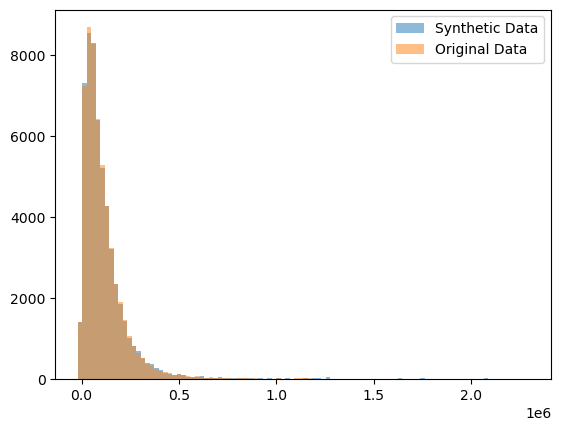

0.507662801687648


In [47]:
# Generate Synthetic Data by dp_histogram
U = X.max()
L = X.min()
bin = 100
epsilon = 0.1

noisy_counts, edges = dp_histogram_laplace(X, bins=bin, data_range=(L, U), epsilon=epsilon, seed=2)
synthetic_data = sample_synthetic_from_dp_hist(noisy_counts, edges, n=len(X), seed=2)

# plot histogram 
plt.hist(synthetic_data, bins=bin, range=(L, U), alpha=0.5, label='Synthetic Data')
plt.hist(X, bins=bin, range=(L, U), alpha=0.5, label='Original Data')
plt.legend()
plt.show()
synthetic_data = np.sort(synthetic_data)
g = cal_gini(synthetic_data)
print(g)

In [10]:
eps = [0.25, 0.5, 1, 1.5, 2]
bins = [50, 100, 200, 400, 500]
U = 1.2*U
n_sample = 10000
# g_syn dim: bins x eps x n_sample
g_syn = np.zeros((len(bins), len(eps), n_sample))

for b_idx, b in enumerate(bins):
    for e_idx, epsilon in enumerate(eps):
        for i in range(n_sample):
            noisy_counts, edges = dp_histogram_laplace(X, bins=b, data_range=(L, U), epsilon=epsilon, seed=i)
            synthetic_data = sample_synthetic_from_dp_hist(noisy_counts, edges, n=len(df_clean), seed=i)
            synthetic_data = np.sort(synthetic_data)
            g = cal_gini(synthetic_data)
            g_syn[b_idx, e_idx, i] = g

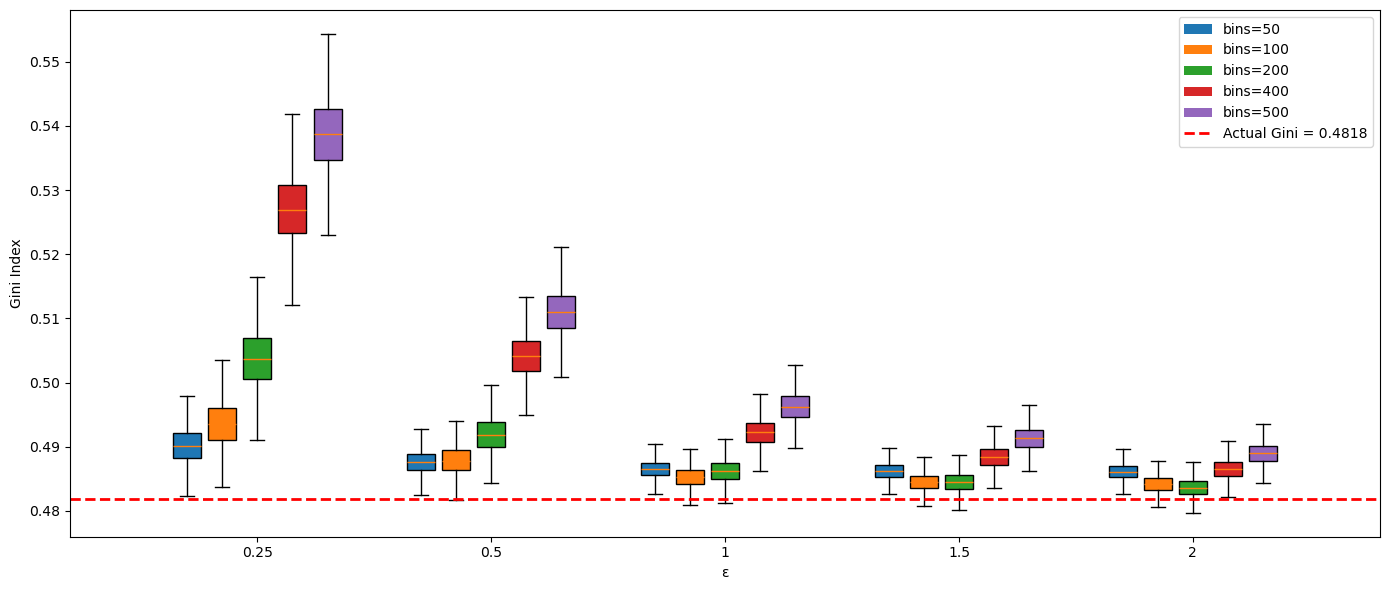

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for grouped boxplot
n_eps = len(eps)
n_bins = len(bins)
positions = []
data = []
colors = plt.cm.tab10.colors[:n_bins]

width = 0.15
group_spacing = 1.0

for e_idx in range(n_eps):
    group_center = e_idx * group_spacing
    for b_idx in range(n_bins):
        pos = group_center + (b_idx - (n_bins - 1) / 2) * width
        positions.append(pos)
        data.append(g_syn[b_idx, e_idx, :n_sample])

# Create boxplot without outliers
bp = ax.boxplot(data, positions=positions, widths=width * 0.8, showfliers=False, patch_artist=True)

# Color the boxes by bin
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % n_bins])

# Create legend for bins
legend_patches = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[i]) for i in range(n_bins)]
ax.legend(legend_patches, [f'bins={b}' for b in bins], loc='upper right')

# Set x-axis labels with epsilon values
ax.set_xticks([i * group_spacing for i in range(n_eps)])
ax.set_xticklabels([f'{e}' for e in eps])
ax.set_xlabel('ε')
ax.set_ylabel('Gini Index')
ax.axhline(y=g_real, color='red', linestyle='--', linewidth=2, label=f'Actual Gini = {g_real:.4f}')

# Add actual Gini line to legend
handles, labels = ax.get_legend_handles_labels()
handles.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2))
labels.append(f'Actual Gini = {g_real:.4f}')
ax.legend(legend_patches + [plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2)], 
          [f'bins={b}' for b in bins] + [f'Actual Gini = {g_real:.4f}'], loc='upper right')

plt.tight_layout()
plt.show()

## Method2: Assume a Pareto Distribution

In [ ]:
def gini(x):
    x = np.asarray(x)
    x = x[x >= 0]                 # ensure non-negative
    if x.size == 0:
        return np.nan
    x = np.sort(x)
    n = x.size
    cumx = np.cumsum(x)
    # G = (n + 1 - 2 * sum_i (cumx_i / cumx_n)) / n
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

print("Gini =", gini(x))